# Curve Fitting and Interpolation Project:


Introduction:

For this project I will be analyzing the Seasonally adjusted annual rate (SAAR) of real
GDP growth, spanning from 2010 Q1 to 2023 Q4. Provided by the  U.S. Bureau of Economic Analysis (BEA). 
For this project I will be using 3 different methods to curve fit and interpolate my data. First, 
I used a cubic spline interpolant constructed by solving a tridiagonal system using the Thomas algorithm, 
guaranteeing passage through every data point with smooth transitions between each of the quarters. Secondly, 
a degree-4 polynomial using least squares via the normal equations derived from the Vandermonde matrix, 
providing a global approximation that captures the overall trend without being constrained to pass through 
individual points. Lastly, I use a  linear least squares model fitted to the dataset that excludes the 
COVID quarters(2020 Q1 - 2021 Q1), allowing assessment of the underlying long-run GDP trend without the pull 
from extreme outliers.


In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 


In [2]:
#Putting The Data into Arrays:

timestamp = [
  '2010 Q1', '2011 Q1', '2012 Q1', '2013 Q1',
  '2014 Q1', '2014 Q3', '2015 Q2', '2016 Q1',
  '2016 Q3', '2016 Q4', '2017 Q1', '2018 Q1',
  '2019 Q1', '2020 Q1', '2020 Q2', '2020 Q3',
  '2021 Q1', '2022 Q1', '2023 Q2', '2023 Q4'
]

"""
    I decided to make a system that uses each quarter as a integer so the passage of 1 qurter is equal to n + 1.
    This is due to the inequal gaps that occur in the problem set, This was the way I was able to make the data
    smooth, and also a easy way to graph all the data points when tasked with filling in the holes.

"""

xvals = [
    0, 4, 8, 12, 16, 18, 21, 24, 26, 27,
    28, 32, 36, 40, 41, 42, 44, 48, 53, 55]

gdp = [
  1.7, 0.1, 2.3, 2.7,
  1.7, 5.0, 3.0, 1.5,
  3.5, 1.8, 1.3, 2.5,
  3.1, -5.1, -28.1, 33.8,
  6.3, -1.6, 2.4, 3.3
]

all_quarters = []
for year in range(2010, 2024):
    for q in range(1 , 5):
        all_quarters.append(f'{year} Q{q}')
    

# Part A: 

In [3]:
def setup_tridiagonal_matrix(xvals, gdp):
    n = len(xvals)
    h = np.diff(xvals) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        if i == 1:
            A[i - 1] = 0
        else:
            A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        if i == n - 2:
            C[i - 1] = 0
        else:
            C[i - 1] = h[i]
        D[i - 1] = 6 * (((gdp[i + 1] - gdp[i]) / h[i]) - ((gdp[i] - gdp[i - 1])/ h[i - 1]))
    return A, B, C, D

In [4]:
def thomas_algorithm(A, B, C, D):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    A: sub-diagonal elements (length n-1)
    B: main diagonal elements (length n)
    C: super-diagonal elements (length n-1)
    D: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(B)
    # Forward elimination
    for i in range(1, n):
        w = A[i-1] / B[i-1]
        B[i] = B[i] - w * C[i-1]
        D[i] = D[i] - w * D[i-1]# Back substitution
    x = np.zeros(n)
    x[-1] = D[-1] / B[-1]
    for i in range(n-2, -1, -1):
        x[i] = (D[i] - C[i] * x[i+1]) / B[i]
    return x
    


In [5]:
A, B, C, D = setup_tridiagonal_matrix(xvals, gdp)

In [6]:
M_int = thomas_algorithm(A, B, C, D)
M = np.zeros(len(xvals))   
M[1:-1] = M_int


In [7]:
def evaluate_spline(xvals, gdp, M, x_eval):
    """
    Each evaluation point is located within its corresponding interval 
    using binary search. The A, B, C, D coefficients are then computed 
    from M values and GDP data points, and the cubic polynomial 
    was evaluated at the local coordinate dx starting from the left knot.
    """
    
    
    
    n = len(xvals)
    h = np.diff(xvals)
    y_eval = np.zeros_like(x_eval, dtype=float)
 
    for k, xv in enumerate(x_eval):
        i = np.searchsorted(xvals, xv, side='right') - 1
        i = int(np.clip(i, 0, n - 2))
 
        dx = xv - xvals[i]
        hi = h[i]
 
        
        a_coef = (M[i + 1] - M[i]) / (6 * hi)
        b_coef = M[i] / 2
        c_coef = (gdp[i + 1] - gdp[i]) / hi - hi * (2 * M[i] + M[i + 1]) / 6
        d_coef = gdp[i]
 
        y_eval[k] = a_coef * dx**3 + b_coef * dx**2 + c_coef * dx + d_coef
 
    return y_eval
 
x_fine = np.linspace(xvals[0], xvals[-1], 500)
y_fine = evaluate_spline(xvals, gdp, M, x_fine)
 


Part A.1:

With 20 data points and 19 intervals between them each interval is 
described by a cubic function with 4 coefficients, resulting in 76 
unknowns. At each of the 18 interior knots three conditions are met: 
The two pieces must meet at the same value, and the first and second
derivatives must match. The last 2 unknowns come from the fact 
this is a natural spline and the curve has no curvature beyond the 
data range. 

In [8]:
x_full = np.linspace(0, 55, len(all_quarters))
y_full = evaluate_spline(xvals, gdp, M, x_full)

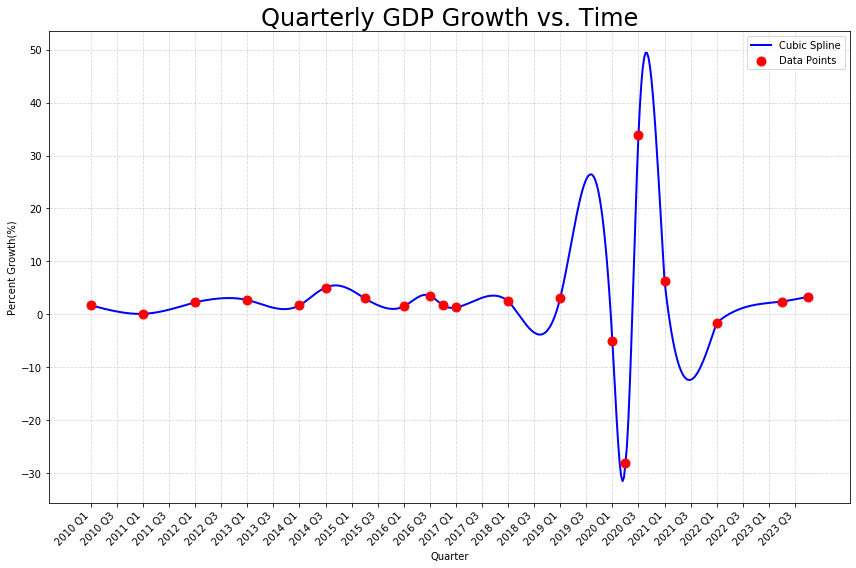

In [9]:
plt.figure(figsize=(12, 8))
plt.plot(x_fine, y_fine, color='b', linewidth=2, label='Cubic Spline')
plt.scatter(xvals, gdp, color='r', zorder=5, s=80, label='Data Points')
plt.title('Quarterly GDP Growth vs. Time', fontsize=24)
plt.xlabel('Quarter')
plt.ylabel('Percent Growth(%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(ticks=x_full[::2], labels=all_quarters[::2], rotation=45, ha='right')
plt.tight_layout()
plt.show()

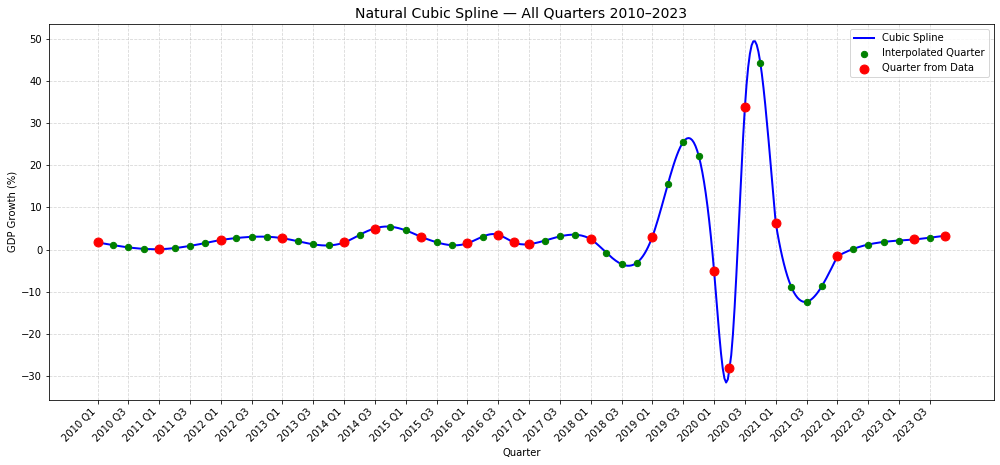

In [10]:
plt.figure(figsize=(14, 8))
plt.plot(x_fine, y_fine, color='b', linewidth=2, label='Cubic Spline')
plt.scatter(x_full, y_full, color='g', zorder=5, s=40, label='Interpolated Quarter')  # 56 evaluated points
plt.scatter(xvals, gdp, color='r', zorder=6, s=80, label='Quarter from Data')       # 20 original points
plt.xticks(ticks=x_full[::2], labels=all_quarters[::2], rotation=45, ha='right')
plt.title('Natural Cubic Spline — All Quarters 2010–2023', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

Part A.2:

The interpolant is visually smooth throughout the range, this is ensured
by the algorithms, and functions used to construct the cubic spline. 
Moreover, the interpolant is reasonable for most of the range. However, 
when the spline has to make rapid and vast transitions during the COVID
quarters the spline overshoots and creates values that didn’t actually occur. 


Part A.3:

The Runge phenomenon is the behavior of interpolants to oscillate between data points when outliers are present. In the data set this is seen between the COVID quarters and is the reason for the overshoots. Exact Interpolation means that the curve is precise and is forced to go through every point, which causes sensitivity to outliers. Numerical stability is a less exact fit that resists the pull of extreme values and produces more intermediate values. Because the outliers are known and they can be singled out, weighted least squares would be more effective. If we did not know which of the data points were the outliers it would then make more sense to smooth the spline. 

# Part B

In [11]:
X = np.array([[x**i for i in range(5)] for x in xvals])
y = np.array(gdp)
XtX = X.T @ X
Xty = X.T @ y
coeffs_4 = np.linalg.solve(XtX, Xty)
y_poly = np.array([sum(coeffs_4[i] * x**i for i in range(5)) for x in x_fine])
print(coeffs_4)


[ 6.03389038e-01  3.71592659e-01 -2.00402788e-02  3.51049873e-04
 -1.71060095e-06]


In [12]:
coeffs_4 = np.linalg.solve(XtX, Xty)
y_poly = np.array([sum(coeffs_4[i] * x**i for i in range(5)) for x in x_fine])

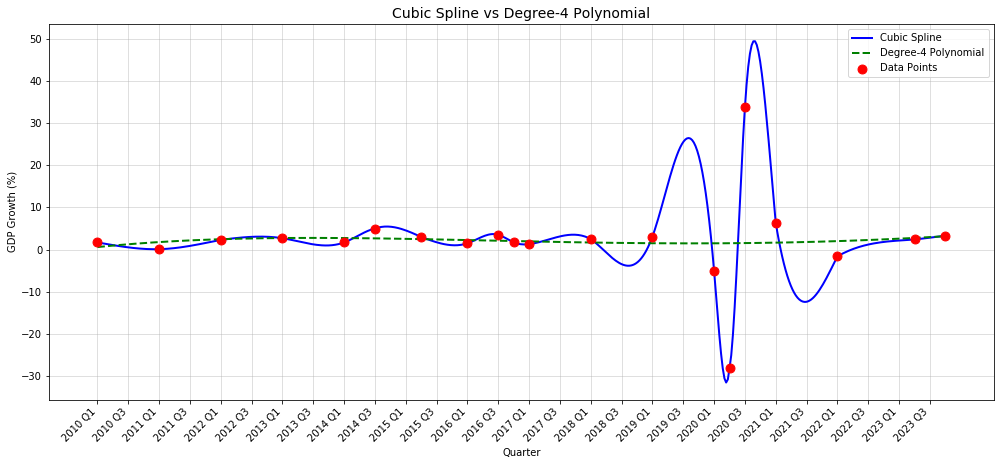

In [13]:
plt.figure(figsize=(14, 8))
plt.plot(x_fine, y_fine, color='b', linewidth=2, label='Cubic Spline')
plt.plot(x_fine, y_poly, color='g', linewidth=2, linestyle='--', label='Degree-4 Polynomial')
plt.scatter(xvals, gdp, color='r', zorder=6, s=80, label='Data Points')
plt.xticks(ticks=x_full[::2], labels=all_quarters[::2], rotation=45, ha='right')
plt.title('Cubic Spline vs Degree-4 Polynomial', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

Part B.1:

The degree-4 polynomial captures the whole trend better. This is because it minimises the total squared error across 
the whole data set. As such it better reflects the GDP growth over the period, while being significantly less affected 
by the COVID outliers. That being said, the spline is still better at reproducing specific data points. The cubic spline 
has high local accuracy that matches every data point, while creating wild oscillation near extreme outliers. 
The degree-4 polynomial only has 5 coefficients across the whole data set so it does not reasonably find local features
but it is able to provide a more strengthened representation of the underlying trends. 


In [14]:
covid_quarters = [40, 41, 42, 44]
xvals_clean = [x for x in xvals if x not in covid_quarters]
gdp_clean = [gdp[i] for i, x in enumerate(xvals) if x not in covid_quarters]

X0 = np.array([[1, x] for x in xvals_clean])
y0 = np.array(gdp_clean)

XtX0 = X0.T @ X0
Xty0 = X0.T @ y0

coeffs = np.linalg.solve(XtX0, Xty0)



In [15]:

y_pred = X0 @ coeffs


ss_res = np.sum((y0 - y_pred) ** 2)         
ss_tot = np.sum((y0 - np.mean(y0)) ** 2)     
r_squared = 1 - (ss_res / ss_tot)
residuals = y0 - y_pred

n = len(y0)
m = 1 
s_y = np.sqrt(ss_res / (n - (m + 1)))

print(f"Standard Error of Estimate: {s_y:.4f}")
print(f"R^2 = {r_squared:.4f}") 

Standard Error of Estimate: 1.5428
R^2 = 0.0004


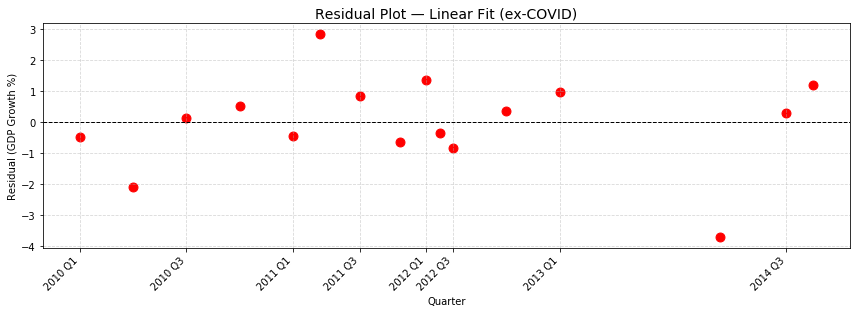

In [16]:

plt.figure(figsize=(12, 5))
plt.scatter(xvals_clean, residuals, color='r', s=80)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Residual Plot — Linear Fit (ex-COVID)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Residual (GDP Growth %)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(ticks=xvals_clean[::2], labels=[all_quarters[xvals.index(x)] for x in xvals_clean[::2]], rotation=45, ha='right')
plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

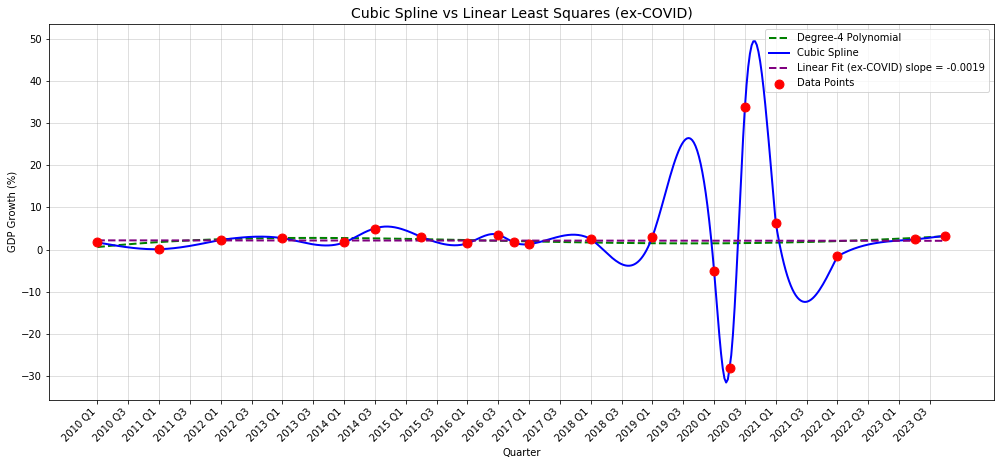

In [17]:
y_linear = coeffs[0] + coeffs[1] * x_fine

plt.figure(figsize=(14, 8))
plt.plot(x_fine, y_poly, color='g', linewidth=2, linestyle='--', label='Degree-4 Polynomial')
plt.plot(x_fine, y_fine, color='b', linewidth=2, label='Cubic Spline')
plt.plot(x_fine, y_linear, color='purple', linewidth=2, linestyle='--',label=f'Linear Fit (ex-COVID) slope = {coeffs[1]:.4f}')
plt.scatter(xvals, gdp, color='r', zorder=6, s=80, label='Data Points')
plt.xticks(ticks=x_full[::2], labels=all_quarters[::2], rotation=45, ha='right')
plt.title('Cubic Spline vs Linear Least Squares (ex-COVID)', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()



Part B.2:

The linear model can be used as a rough summary, The near zero slope shows that GDP growth was stable across the data set excluding the COVID shock. However the Linear model is not sophisticated enough to be able to be utilized for meaningful economic analysis of the data. Moreover, This data does not show a strong relationship between the data and the linear trend predicted (R^2 = 0.0004) The proximity of this number to 0 coupled by the slope being m = -0.0019 shows that the GDP does not result in a net growth. This is supported by the data and the approximations.


# Part C:

Part C.1:

To answer Part C nuance must be used to provide ample evidence to support a rational answer. If the data set exudes the outliers (COVID) the cubic splines inherent piecewise, and passage through all data points would allow it to be the most effective for a policy maker to interpolate between points. However, when using the fact that the outliers are present it is best to use the 4 Degree-polynomial, because it is not forced to go through all of the data points, all the while maintaining some semblance of curvature when compared to the Linear model. 

Part C addendum:

Big O notation describes how an algorithm’s runtime is affected by the input size. It is a great way to evaluate the algorithms that are used independent of the hardware. 
Method      
Solving for the Setup: Solve: Evaluate: of each of the methods





Cubic Spline: (O(n), O(n), O(m log n))


Degree-4 Polynomial:             (O(n), O(1)*, O(m)


Linear Least Squares:            (O(n), O(1)*, O(m))

Big O analysis solidifies that the cubic spline is the least computationally expensive. The structure of the algorithms means that adding new data points only requires updating neighboring intervals. Not refitting the entire model as the other two would require


In [18]:
import time

ns = list(range(10, 500, 10))
times_spline = []
times_poly = []
times_linear = []

for n in ns:
    x = np.linspace(0, 55, n)
    y = np.sin(x) + np.random.normal(0, 0.1, n)  # synthetic data
    
    # Cubic Spline
    t0 = time.time()
    A0, B0, C0, D0 = setup_tridiagonal_matrix(x, y)
    M_int = thomas_algorithm(A0, B0, C0, D0)
    M_temp = np.zeros(n)
    M_temp[1:-1] = M_int
    evaluate_spline(x, y, M_temp, np.linspace(x[0], x[-1], 500))
    times_spline.append(time.time() - t0)
    
    # Degree-4 Polynomial
    t0 = time.time()
    X = np.array([[xi**i for i in range(5)] for xi in x])
    coeffs_t = np.linalg.solve(X.T @ X, X.T @ y)
    np.array([sum(coeffs_t[i] * xi**i for i in range(5)) for xi in np.linspace(x[0], x[-1], 500)])
    times_poly.append(time.time() - t0)
    
    # Linear
    t0 = time.time()
    X0 = np.array([[1, xi] for xi in x])
    coeffs_t = np.linalg.solve(X0.T @ X0, X0.T @ y)
    coeffs_t[0] + coeffs_t[1] * np.linspace(x[0], x[-1], 500)
    times_linear.append(time.time() - t0)


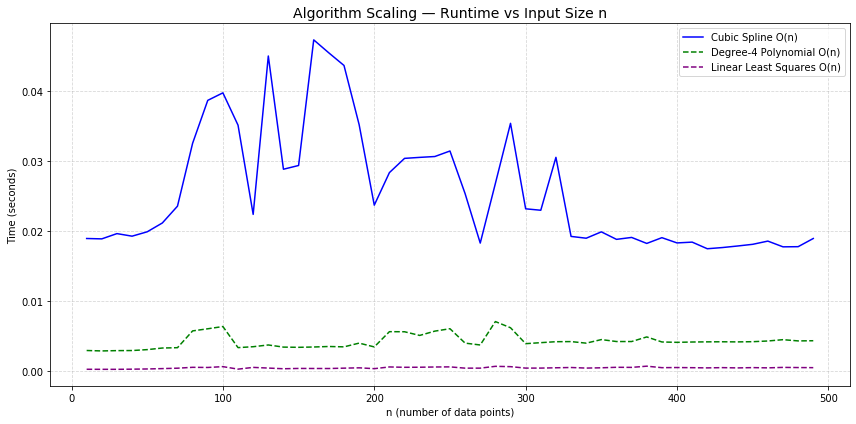

In [19]:

plt.figure(figsize=(12, 6))
plt.plot(ns, times_spline, label='Cubic Spline O(n)', color='b')
plt.plot(ns, times_poly, label='Degree-4 Polynomial O(n)', color='g', linestyle='--')
plt.plot(ns, times_linear, label='Linear Least Squares O(n)', color='purple', linestyle='--')
plt.title('Algorithm Scaling — Runtime vs Input Size n', fontsize=14)
plt.xlabel('n (number of data points)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Conclusion 

This project has taught me a lot about data analysis. I was able to pull from my internship last summer which I spent designing a Data-Plotter in python. I enjoyed learning about these more advanced techniques for data analysis. The three different methods all performed different tasks with different methods to accomplish them. The Cubic Spline is the most effective at interpolating but has the most sensitivity when regarding the covid outliers. The Linear Regression is a brute force, strengthened method that is strong at resisting outliers and being able to see global trends across the whole data set. The 4 Degree-Polynomial is a nice in between where it is still able to capture curvature but is still resistant to the outliers, this rendered it the best at finding the trend in a more local way then the Linear model.